In [ ]:
!pip install kaggle

from google.colab import files
files.upload()

#username : me23b2016 ; upload the kaggle.json file 

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"cs23i1004","key":"d2be394d67c9feac873c2b8177e450c3"}'}

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip lgg-mri-segmentation.zip   # loading the dataset 

Streaming output truncated to the last 5000 lines.
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7294_19890104/TCGA_DU_7294_19890104_9_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_1.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_13.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_1

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.manifold import TSNE

In [ ]:
image_paths = sorted(glob("lgg-mri-segmentation/kaggle_3m/*/*_mask.tif"))

normal_images = []
abnormal_images = []

for mask_path in image_paths:

    img_path = mask_path.replace("_mask","")

    mask = cv2.imread(mask_path,0)

    img = cv2.imread(img_path,0)
    img = cv2.resize(img,(128,128))
    img = img/255.0

    if np.sum(mask) == 0:
        normal_images.append(img)
    else:
        abnormal_images.append(img)

normal_images = np.array(normal_images)
abnormal_images = np.array(abnormal_images)

print("Normal:",len(normal_images))
print("Abnormal:",len(abnormal_images))

class MRIDataset(Dataset):   # Class to load the dataset

    def __init__(self, images):
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self,idx):

        img = self.images[idx]
        img = np.expand_dims(img,0)

        return torch.tensor(img,dtype=torch.float32)

dataset = MRIDataset(normal_images)
loader = DataLoader(dataset,batch_size=32,shuffle=True)      

Normal: 2556
Abnormal: 1373


In [ ]:
#Classes for encoder, decoder, VAE
class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,32,4,2,1),
            nn.ReLU(),
            nn.Conv2d(32,64,4,2,1),
            nn.ReLU(),
            nn.Conv2d(64,128,4,2,1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128*16*16,64)
        self.fc_logvar = nn.Linear(128*16*16,64)

    def forward(self,x):

        x = self.conv(x)
        x = x.view(x.size(0),-1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu,logvar

class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(64,128*16*16)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,2,1),
            nn.Sigmoid()
        )

    def forward(self,z):

        x = self.fc(z)
        x = x.view(-1,128,16,16)
        x = self.deconv(x)

        return x

class VAE(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self,mu,logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std

    def forward(self,x):

        mu,logvar = self.encoder(x)
        z = self.reparameterize(mu,logvar)

        recon = self.decoder(z)

        return recon,mu,logvar

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = VAE().to(device)

optimizer = optim.Adam(vae.parameters(),lr=1e-3)

losses = []

for epoch in range(20):

    epoch_loss = 0

    for img in loader:

        img = img.to(device)

        recon,mu,logvar = vae(img)

        recon_loss = nn.functional.mse_loss(recon,img)

        kl_loss = -0.5*torch.mean(
            1 + logvar - mu.pow(2) - logvar.exp()
        )

        loss = recon_loss + kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss)

    print("Epoch",epoch,"Loss",epoch_loss)

Epoch 0 Loss 3.0443756356835365
Epoch 1 Loss 0.9311269912868738
Epoch 2 Loss 0.8056404674425721
Epoch 3 Loss 0.7913293251767755
Epoch 4 Loss 0.7847135658375919
Epoch 5 Loss 0.786044976208359
Epoch 6 Loss 0.7853774251416326
Epoch 7 Loss 0.7819063942879438
Epoch 8 Loss 0.7793137091211975
Epoch 9 Loss 0.7777469521388412
Epoch 10 Loss 0.7766554267145693
Epoch 11 Loss 0.7771762507036328
Epoch 12 Loss 0.7747304923832417
Epoch 13 Loss 0.7758792145177722
Epoch 14 Loss 0.773319155909121
Epoch 15 Loss 0.7776143136434257
Epoch 16 Loss 0.769142912235111
Epoch 17 Loss 0.7716476246714592
Epoch 18 Loss 0.7747006956487894
Epoch 19 Loss 0.7716734576970339


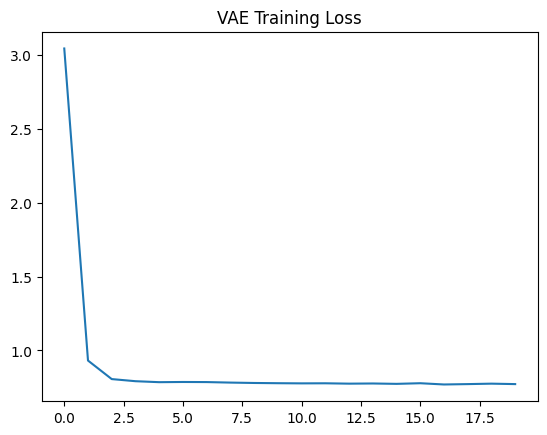

In [ ]:
plt.plot(losses)
plt.title("VAE Training Loss")
plt.show()

In [ ]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(100,128*16*16)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,2,1),
            nn.Tanh()
        )

    def forward(self,z):

        x = self.fc(z)
        x = x.view(-1,128,16,16)

        return self.deconv(x)

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(1,32,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128*16*16,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

opt_G = optim.Adam(G.parameters(),lr=0.0002)
opt_D = optim.Adam(D.parameters(),lr=0.0002)

criterion = nn.BCELoss()

for epoch in range(20):

    for real in loader:

        real = real.to(device)
        batch = real.size(0)

        real_labels = torch.ones(batch,1).to(device)
        fake_labels = torch.zeros(batch,1).to(device)

        # Train Discriminator
        z = torch.randn(batch,100).to(device)
        fake = G(z)

        d_real = D(real)
        d_fake = D(fake.detach())

        loss_D = criterion(d_real,real_labels) + criterion(d_fake,fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        z = torch.randn(batch,100).to(device)
        fake = G(z)

        output = D(fake)

        loss_G = criterion(output,real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(epoch,loss_D.item(),loss_G.item())

0 0.29258739948272705 3.9257047176361084
1 0.007882819510996342 14.25490665435791
2 0.0017268911469727755 66.16463470458984
3 0.0013976593036204576 23.860258102416992
4 0.08759263157844543 22.816463470458984
5 1.145467758178711 2.315255880355835
6 0.2791241407394409 3.1949191093444824
7 0.3932077884674072 6.464823246002197
8 1.8806977272033691 1.441977858543396
9 0.9267306327819824 1.9258068799972534
10 0.3748442828655243 3.6734347343444824
11 0.9290830492973328 2.1359775066375732
12 1.3206431865692139 2.331958770751953
13 0.5808162689208984 10.20594310760498
14 0.5136650800704956 3.25028657913208
15 1.154868721961975 1.3711639642715454
16 4.388998031616211 1.094753384590149
17 0.913193941116333 8.182942390441895
18 0.019866755232214928 6.498770236968994
19 0.5390638113021851 4.166505336761475


In [ ]:
test = abnormal_images[0]

test = torch.tensor(test).unsqueeze(0).unsqueeze(0).float().to(device)

recon,_ ,_ = vae(test)

recon = recon.cpu().detach().numpy()[0][0]
test = test.cpu().numpy()[0][0]

diff = np.abs(test - recon)

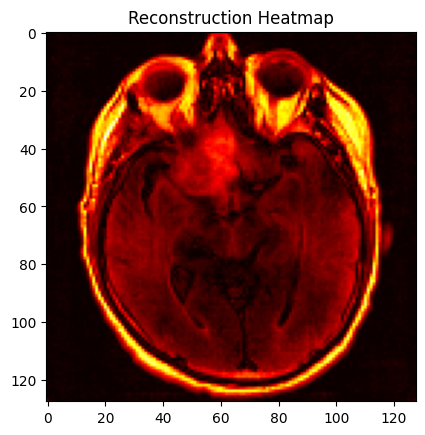

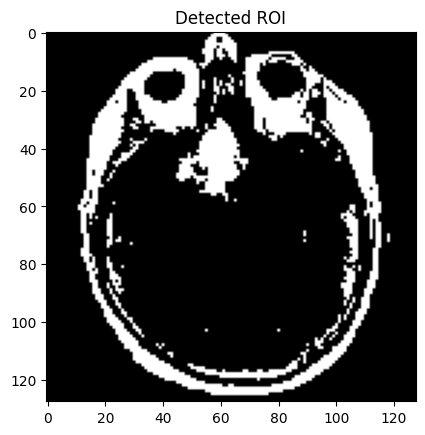

In [ ]:
plt.imshow(diff,cmap='hot')
plt.title("Reconstruction Heatmap")
plt.show()

roi = diff > 0.15

plt.imshow(roi,cmap='gray')
plt.title("Detected ROI")
plt.show()

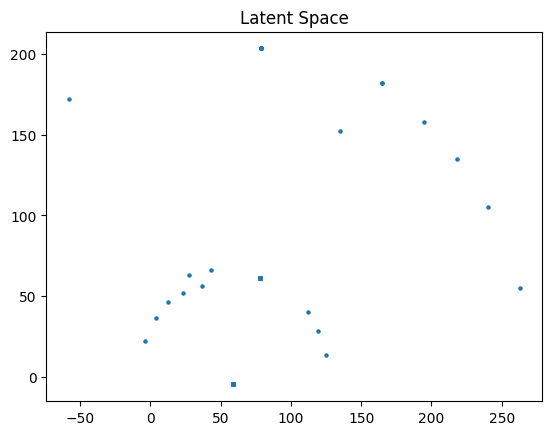

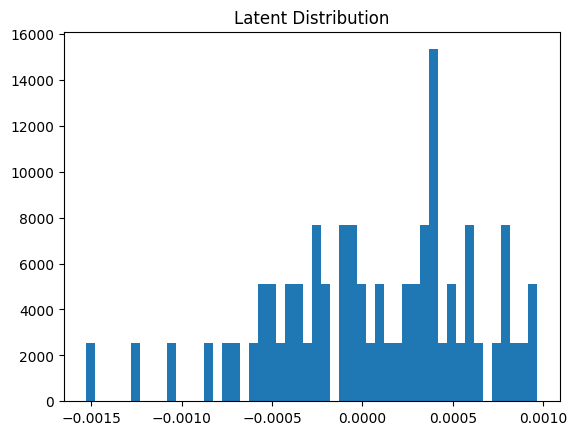

In [ ]:
latents = []

for img in loader:

    img = img.to(device)

    mu,_ = vae.encoder(img)

    latents.append(mu.cpu().detach().numpy())

latents = np.concatenate(latents)

tsne = TSNE(n_components=2)

latent_2d = tsne.fit_transform(latents)

plt.scatter(latent_2d[:,0],latent_2d[:,1],s=5)
plt.title("Latent Space")
plt.show()

plt.hist(latents.flatten(),bins=50)
plt.title("Latent Distribution")
plt.show()  #Latent space and distrubution

In [ ]:
edges = cv2.Canny((roi*255).astype(np.uint8),100,200)

edge_count = np.sum(edges>0)
print(edge_count)

noise_ratio = np.sum(roi)/roi.size
print(noise_ratio)



1475
0.1768798828125
